# PhoBERT Large

| Model | Params | Batch | Grad Accum |
|-------|--------|-------|------------|
| vinai/phobert-large | 370M | 4 | 4 |

Model lớn nên batch=4, dùng gradient accumulation=4 để effective batch=16.

**Mục đích**: Fine-tune để model học domain → extract embeddings

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.empty_cache()  # Clear cache for large model

CUDA: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
from src.s2_finetuning.s1_functions import BertFineTuner

MODEL_KEY = 'phobert-large'
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / '02_final.csv'

tuner = BertFineTuner(MODEL_KEY)

d:\Vietnamese-Fake-News-Detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



CUDA is available - using GPU: NVIDIA GeForce RTX 3050 Laptop GPU
BERT Fine-Tuner: PhoBERT Large - 370M params
Model: vinai/phobert-large
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.0 GB
Max Length: 256
Batch Size: 4

Loading tokenizer and model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded!


In [3]:
tuner.load_data(str(DATA_PATH), text_col='text_bert', label_col='label', test_size=0.2, val_size=0.1)


Loading data from: d:\Vietnamese-Fake-News-Detection\data\processed\02_final.csv
Total samples: 4734
Label distribution: 0=3927, 1=807

Data splits:
  Train: 3313 samples
  Val:   474 samples
  Test:  947 samples
✓ Data loaded!


In [4]:
# Gradient accumulation = 4 để effective batch = 4 * 4 = 16
tuner.train(epochs=3, learning_rate=2e-5, gradient_accumulation_steps=4, save_best=True)


TRAINING
Epochs: 3
Learning Rate: 2e-05
Effective Batch Size: 16

--- Epoch 1/3 ---


Training: 100%|██████████| 829/829 [2:07:31<00:00,  9.23s/it, loss=0.0307]     


Train Loss: 0.4647
Val Loss: 0.3862 | Val Acc: 0.8291 | Val F1: 0.4533
✓ New best model! F1: 0.4533

--- Epoch 2/3 ---


Training: 100%|██████████| 829/829 [1:29:06<00:00,  6.45s/it, loss=0.0058]


Train Loss: 0.2829
Val Loss: 0.2733 | Val Acc: 0.9008 | Val F1: 0.8276
✓ New best model! F1: 0.8276

--- Epoch 3/3 ---


Training: 100%|██████████| 829/829 [1:30:04<00:00,  6.52s/it, loss=0.0044]


Train Loss: 0.1651
Val Loss: 0.3836 | Val Acc: 0.9114 | Val F1: 0.8103

✓ Loaded best model with F1: 0.8276

Training completed!


In [5]:
# Evaluate để biết model đã học tốt chưa
metrics = tuner.evaluate_test()
print("\n→ Metrics cao = model đã hiểu domain tốt")


TEST SET EVALUATION


Evaluating: 100%|██████████| 237/237 [00:45<00:00,  5.23it/s]



Results:
  Accuracy:       0.9071
  F1 (macro):     0.8345
  F1 (weighted):  0.9068
  Precision:      0.8362
  Recall:         0.8329
  F1 (Fake):      0.7250
  F1 (Real):      0.9441

→ Metrics cao = model đã hiểu domain tốt


In [6]:
# Save model
SAVE_PATH = PROJECT_ROOT / 'models' / 'bert_embedding' / f'{MODEL_KEY}-finetuned'
tuner.save(str(SAVE_PATH))


Saving model to: d:\Vietnamese-Fake-News-Detection\models\bert_embedding\phobert-large-finetuned
✓ Model saved!
  - model files: d:\Vietnamese-Fake-News-Detection\models\bert_embedding\phobert-large-finetuned
  - config: d:\Vietnamese-Fake-News-Detection\models\bert_embedding\phobert-large-finetuned\training_config.json


In [7]:
# QUAN TRỌNG: Extract embeddings từ model đã fine-tune
EMBEDDING_PATH = PROJECT_ROOT / 'data' / 'encoded' / f'{MODEL_KEY}_embeddings.npy'

embeddings = tuner.extract_and_save_embeddings(
    data_path=str(DATA_PATH),
    output_path=str(EMBEDDING_PATH),
    text_col='text_bert',
    pooling='cls'  # hoặc 'mean'
)

print(f"\n→ Embeddings shape: {embeddings.shape}")
print(f"→ Dùng file này cho training classifier riêng")


Extracting embeddings from: d:\Vietnamese-Fake-News-Detection\data\processed\02_final.csv


Extracting embeddings: 100%|██████████| 1184/1184 [09:46<00:00,  2.02it/s]

✓ Saved embeddings: d:\Vietnamese-Fake-News-Detection\data\encoded\phobert-large_embeddings.npy
  Shape: (4736, 1024)
  Pooling: cls

→ Embeddings shape: (4736, 1024)
→ Dùng file này cho training classifier riêng


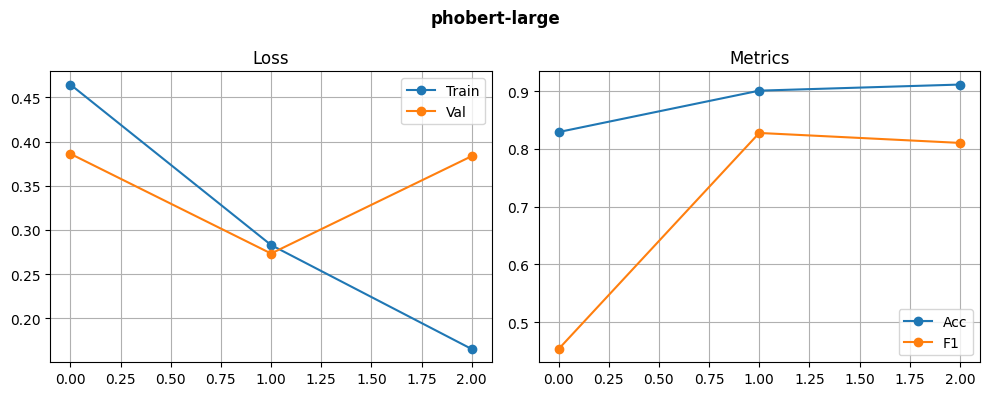

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(tuner.history['train_loss'], 'o-', label='Train')
axes[0].plot(tuner.history['val_loss'], 'o-', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(tuner.history['val_acc'], 'o-', label='Acc')
axes[1].plot(tuner.history['val_f1'], 'o-', label='F1')
axes[1].set_title('Metrics'); axes[1].legend(); axes[1].grid(True)

plt.suptitle(f'{MODEL_KEY}', fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'figures' / f'{MODEL_KEY}_history.png', dpi=150)
plt.show()

In [9]:
# Free GPU memory
import gc
del tuner
gc.collect()
torch.cuda.empty_cache()